In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/boshramahbub/ecommerce/ecommerce_customer_behavior_dataset.csv


In [4]:
import pandas as pd
df=pd.read_csv("/kaggle/input/datasets/boshramahbub/ecommerce/ecommerce_customer_behavior_dataset.csv")

In [5]:
df

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,ORD_001048,CUST_01048,2024-03-26,18,Female,Izmir,Beauty,130.35,1,27.30,103.05,Bank Transfer,Mobile,17,10,False,9,1
4996,ORD_001051,CUST_01051,2024-03-26,27,Male,Adana,Beauty,71.55,1,0.00,71.55,Debit Card,Mobile,13,9,True,6,4
4997,ORD_003543,CUST_03543,2024-03-26,45,Female,Antalya,Food,39.38,1,5.27,34.11,Digital Wallet,Mobile,38,10,True,5,4
4998,ORD_004443,CUST_04443,2024-03-26,41,Female,Istanbul,Fashion,171.19,1,0.00,171.19,Credit Card,Mobile,20,12,True,5,4


In [6]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   object 
 1   Customer_ID               5000 non-null   object 
 2   Date                      5000 non-null   object 
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   object 
 5   City                      5000 non-null   object 
 6   Product_Category          5000 non-null   object 
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Discount_Amount           5000 non-null   float64
 10  Total_Amount              5000 non-null   float64
 11  Payment_Method            5000 non-null   object 
 12  Device_Type               5000 non-null   object 
 13  Session_Duration_Minutes  5000 non-null   int64  
 14  Pages_Vi

In [7]:
df.describe()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000
mean,35.032600,455.834120,2.220000,24.852804,983.108914,14.57340,8.98420,6.497000,3.902800
std,11.080546,712.477209,1.398711,88.385124,1898.978528,8.66575,2.80434,3.464966,1.128542
min,18.000000,5.180000,1.000000,0.000000,7.870000,1.00000,1.00000,1.000000,1.000000
25%,27.000000,76.587500,1.000000,0.000000,122.517500,8.00000,7.00000,4.000000,3.000000
50%,35.000000,182.950000,2.000000,0.000000,337.910000,13.00000,9.00000,6.000000,4.000000
75%,42.000000,513.930000,3.000000,8.760000,979.695000,19.00000,11.00000,8.000000,5.000000
max,75.000000,7159.450000,5.000000,1525.550000,22023.900000,73.00000,24.00000,25.000000,5.000000


In [8]:
df.isnull().sum()


Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.select_dtypes(include='number').columns

Index(['Age', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Total_Amount',
       'Session_Duration_Minutes', 'Pages_Viewed', 'Delivery_Time_Days',
       'Customer_Rating'],
      dtype='object')

# Task 1: Load Your Dataset

In [11]:
df.head(5)


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


In [12]:
df.select_dtypes(include='object').shape[1]

8

In [13]:
len(df.columns)

18


**Questions
1 What does one row represent?
2 What does one column represent?
3 How many data objects are present?
4 How many attributes are present?**


ANS-1
One row represent order information 
ANS-2 
A column represents one attribute or feature of the data.
ANS-3 8
ANS-4 18


# Task 2: Identify Data Objects

In [14]:
df.shape

(5000, 18)

Number of data objects 5000. Number of attributes 18
One data object in our dataset represents one complete order made by one customer.


# Task 3: Identify All Attributes

In [15]:
# Display the attributes:
df.columns


Index(['Order_ID', 'Customer_ID', 'Date', 'Age', 'Gender', 'City',
       'Product_Category', 'Unit_Price', 'Quantity', 'Discount_Amount',
       'Total_Amount', 'Payment_Method', 'Device_Type',
       'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer',
       'Delivery_Time_Days', 'Customer_Rating'],
      dtype='object')

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   object 
 1   Customer_ID               5000 non-null   object 
 2   Date                      5000 non-null   object 
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   object 
 5   City                      5000 non-null   object 
 6   Product_Category          5000 non-null   object 
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Discount_Amount           5000 non-null   float64
 10  Total_Amount              5000 non-null   float64
 11  Payment_Method            5000 non-null   object 
 12  Device_Type               5000 non-null   object 
 13  Session_Duration_Minutes  5000 non-null   int64  
 14  Pages_Vi

In [17]:
import pandas as pd

# Define data
data = {
    "Attribute": [
        "Order_ID",
        "Customer_ID",
        "Date",
        "Age",
        "Gender",
        "City",
        "Product_Category",
        "Unit_Price",
        "Quantity",
        "Discount_Amount",
        "Total_Amount",
        "Payment_Method",
        "Device_Type",
        "Session_Duration_Minutes",
        "Pages_Viewed",
        "Is_Returning_Customer",
        "Delivery_Time_Days",
        "Customer_Rating"
    ],

    "Description": [
        "Unique identifier of the order",
        "Unique identifier of the customer",
        "Date when the order was made",
        "Age of the customer",
        "Gender of the customer",
        "City of the customer",
        "Category of the purchased product",
        "Price of one product unit",
        "Number of products purchased",
        "Amount of discount applied",
        "Total amount of the order",
        "Method used for payment",
        "Device used for shopping",
        "Duration of the shopping session in minutes",
        "Number of pages viewed during the session",
        "Whether the customer is a returning customer",
        "Number of days taken for delivery",
        "Rating given by the customer"
    ],

    "Python Data Type": [
        "object",
        "object",
        "object",
        "int64",
        "object",
        "object",
        "object",
        "float64",
        "int64",
        "float64",
        "float64",
        "object",
        "object",
        "int64",
        "int64",
        "bool",
        "int64",
        "int64"
    ],

    "Data-Mining Type": [
        "Nominal",
        "Nominal",
        "Temporal",
        "Discrete",
        "Nominal",
        "Nominal",
        "Nominal",
        "Continuous",
        "Discrete",
        "Continuous",
        "Continuous",
        "Nominal",
        "Nominal",
        "Discrete",
        "Discrete",
        "Binary",
        "Discrete",
        "Ordinal"
    ]
}

# Create DataFrame
attribute_table = pd.DataFrame(data)

# Display table
attribute_table

,Attribute,Description,Python Data Type,Data-Mining Type
0,Order_ID,Unique identifier of the order,object,Nominal
1,Customer_ID,Unique identifier of the customer,object,Nominal
2,Date,Date when the order was made,object,Temporal
3,Age,Age of the customer,int64,Discrete
4,Gender,Gender of the customer,object,Nominal
5,City,City of the customer,object,Nominal
6,Product_Category,Category of the purchased product,object,Nominal
7,Unit_Price,Price of one product unit,float64,Continuous
8,Quantity,Number of products purchased,int64,Discrete
9,Discount_Amount,Amount of discount applied,float64,Continuous


# Task 4: Classify Attribute Types

In [18]:
import pandas as pd

# Define data
data = {
    "Attribute": [
        "Order_ID",
        "Customer_ID",
        "Date",
        "Age",
        "Gender",
        "City",
        "Product_Category",
        "Unit_Price",
        "Quantity",
        "Discount_Amount",
        "Total_Amount",
        "Payment_Method",
        "Device_Type",
        "Session_Duration_Minutes",
        "Pages_Viewed",
        "Is_Returning_Customer",
        "Delivery_Time_Days",
        "Customer_Rating"
    ],

    "Attribute Type": [
        "Nominal",
        "Nominal",
        "Temporal",
        "Discrete",
        "Nominal",
        "Nominal",
        "Nominal",
        "Continuous",
        "Discrete",
        "Continuous",
        "Continuous",
        "Nominal",
        "Nominal",
        "Discrete",
        "Discrete",
        "Binary",
        "Discrete",
        "Ordinal"
    ],

    "Reason": [
        "Identifier with no meaningful order",
        "Identifier with no meaningful order",
        "Represents a date",
        "Countable numerical value",
        "Categories without order",
        "Categories without order",
        "Categories without order",
        "Measured numerical quantity",
        "Countable numerical value",
        "Measured numerical quantity",
        "Measured numerical quantity",
        "Categories without order",
        "Categories without order",
        "Countable numerical value",
        "Countable numerical value",
        "Only two possible states: True or False",
        "Countable numerical value",
        "Ordered categories from 1 to 5"
    ]
}

# Create DataFrame
attribute_type_table = pd.DataFrame(data)

# Display table
attribute_type_table

,Attribute,Attribute Type,Reason
0,Order_ID,Nominal,Identifier with no meaningful order
1,Customer_ID,Nominal,Identifier with no meaningful order
2,Date,Temporal,Represents a date
3,Age,Discrete,Countable numerical value
4,Gender,Nominal,Categories without order
5,City,Nominal,Categories without order
6,Product_Category,Nominal,Categories without order
7,Unit_Price,Continuous,Measured numerical quantity
8,Quantity,Discrete,Countable numerical value
9,Discount_Amount,Continuous,Measured numerical quantity


# Task 5: Explore Numerical Attributes

In [19]:
import numpy as np
numeric_columns = df.select_dtypes(
    include=np.number
).columns

print(numeric_columns)


df[numeric_columns].describe()



Index(['Age', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Total_Amount',
       'Session_Duration_Minutes', 'Pages_Viewed', 'Delivery_Time_Days',
       'Customer_Rating'],
      dtype='object')


,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000
mean,35.032600,455.834120,2.220000,24.852804,983.108914,14.57340,8.98420,6.497000,3.902800
std,11.080546,712.477209,1.398711,88.385124,1898.978528,8.66575,2.80434,3.464966,1.128542
min,18.000000,5.180000,1.000000,0.000000,7.870000,1.00000,1.00000,1.000000,1.000000
25%,27.000000,76.587500,1.000000,0.000000,122.517500,8.00000,7.00000,4.000000,3.000000
50%,35.000000,182.950000,2.000000,0.000000,337.910000,13.00000,9.00000,6.000000,4.000000
75%,42.000000,513.930000,3.000000,8.760000,979.695000,19.00000,11.00000,8.000000,5.000000
max,75.000000,7159.450000,5.000000,1525.550000,22023.900000,73.00000,24.00000,25.000000,5.000000


# Task 6: Explore Categorical Attributes


In [20]:

categorical_columns = df.select_dtypes(
    include="object"
).columns

print(categorical_columns)


Index(['Order_ID', 'Customer_ID', 'Date', 'Gender', 'City', 'Product_Category',
       'Payment_Method', 'Device_Type'],
      dtype='object')


In [21]:
df["Product_Category"].value_counts()


Product_Category
Sports           667
Electronics      624
Fashion          622
Beauty           621
Home & Garden    621
Food             619
Books            616
Toys             610
Name: count, dtype: int64

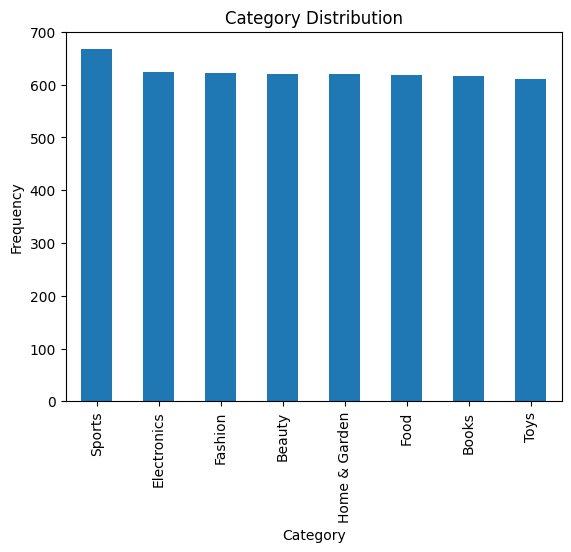

In [22]:
# Visualize it:
import matplotlib.pyplot as plt
df["Product_Category"].value_counts().plot(
    kind="bar"
)

plt.xlabel("Category")
plt.ylabel("Frequency")
plt.title("Category Distribution")
plt.show()


# Task 7: Find Missing Values

In [23]:
df.isnull().sum()

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

In [24]:
missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

print(missing_percentage)



Order_ID                    0.0
Customer_ID                 0.0
Date                        0.0
Age                         0.0
Gender                      0.0
City                        0.0
Product_Category            0.0
Unit_Price                  0.0
Quantity                    0.0
Discount_Amount             0.0
Total_Amount                0.0
Payment_Method              0.0
Device_Type                 0.0
Session_Duration_Minutes    0.0
Pages_Viewed                0.0
Is_Returning_Customer       0.0
Delivery_Time_Days          0.0
Customer_Rating             0.0
dtype: float64


In [25]:
# Create missing values table

missing_table = pd.DataFrame({
    "Attribute": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing Percentage": (df.isnull().sum().values / len(df) * 100)
})

missing_table

,Attribute,Missing Values,Missing Percentage
0,Order_ID,0,0.0
1,Customer_ID,0,0.0
2,Date,0,0.0
3,Age,0,0.0
4,Gender,0,0.0
5,City,0,0.0
6,Product_Category,0,0.0
7,Unit_Price,0,0.0
8,Quantity,0,0.0
9,Discount_Amount,0,0.0


# Task 8: Find Duplicate Records

In [26]:
df.duplicated().sum()


df[df.duplicated()]



,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating


# Task 9: Detect Inconsistent Values

In [27]:
df["Gender"].unique()



array(['Female', 'Male', 'Other'], dtype=object)

In [28]:
df["City"].unique()

array(['Bursa', 'Konya', 'Ankara', 'Istanbul', 'Izmir', 'Eskisehir',
       'Antalya', 'Kayseri', 'Gaziantep', 'Adana'], dtype=object)

In [29]:
df["Product_Category"].unique()

array(['Toys', 'Food', 'Electronics', 'Sports', 'Beauty', 'Fashion',
       'Home & Garden', 'Books'], dtype=object)

In [30]:
df["Payment_Method"].unique()

array(['Debit Card', 'Credit Card', 'Cash on Delivery', 'Digital Wallet',
       'Bank Transfer'], dtype=object)

In [31]:
# Check unusually high delivery times
df[df["Delivery_Time_Days"] > 15]

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
31,ORD_003301,CUST_03301,2023-01-04,39,Female,Ankara,Home & Garden,724.61,2,74.60,1374.62,Credit Card,Desktop,30,13,False,17,5
37,ORD_002957,CUST_02957,2023-01-05,46,Female,Istanbul,Books,46.09,4,0.00,184.36,Debit Card,Desktop,14,11,True,17,4
162,ORD_000533,CUST_00533,2023-01-19,34,Female,Antalya,Food,61.34,1,13.77,47.57,Digital Wallet,Desktop,27,9,False,16,4
170,ORD_000626,CUST_00626,2023-01-20,28,Male,Gaziantep,Books,60.16,1,13.38,46.78,Debit Card,Desktop,10,3,True,16,4
222,ORD_001726,CUST_01726,2023-01-24,48,Male,Ankara,Electronics,475.66,1,0.00,475.66,Cash on Delivery,Mobile,4,3,True,16,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4765,ORD_003872,CUST_03872,2024-03-05,36,Male,Adana,Beauty,65.09,4,12.37,247.99,Debit Card,Tablet,20,11,False,20,5
4775,ORD_004285,CUST_04285,2024-03-07,25,Male,Izmir,Beauty,57.77,5,0.00,288.85,Debit Card,Mobile,15,6,False,24,4
4896,ORD_000369,CUST_00369,2024-03-18,36,Male,Istanbul,Toys,140.33,4,0.00,561.32,Credit Card,Mobile,19,7,False,17,2
4904,ORD_001406,CUST_01406,2024-03-18,25,Male,Bursa,Books,50.02,3,13.87,136.19,Debit Card,Desktop,20,6,False,18,4


Some orders have unusually long delivery times, with a maximum of 24 days compared with a median of 6 days. These values were flagged for further investigation rather than removed, because they may represent genuine delivery delays

# Task 10: Identify Irrelevant or Identifier Attributes

1. Which attributes are identifiers?

Order_ID
Customer_ID

2. Why should identifiers generally not be treated as numerical measurements?

   
Identifiers are used only to uniquely identify records. Their values do not represent measurable quantities, so mathematical operations on them have no meaningful interpretation.

4. Should these attributes be used as predictive/mining features? Explain.
   
Generally, no. Order_ID and Customer_ID should not be used as predictive features because they do not provide meaningful information about customer behavior or order outcomes. They should mainly be used for identification and tracking records.

In [32]:
df = df.drop(columns=["Order_ID", "Customer_ID"])

# Task 11: Investigate Attribute Variation

In [33]:
df.nunique()

Date                         451
Age                           57
Gender                         3
City                          10
Product_Category               8
Unit_Price                  4785
Quantity                       5
Discount_Amount             1405
Total_Amount                4868
Payment_Method                 5
Device_Type                    3
Session_Duration_Minutes      58
Pages_Viewed                  22
Is_Returning_Customer          2
Delivery_Time_Days            25
Customer_Rating                5
dtype: int64

1.Which attribute has the largest number of unique values?

   Answer: Total_Amount
   
2.Which has the smallest?

 Answer: Is_Returning_Customer
 
3.Does any attribute contain only one unique value?

 Answer:NO
 
4.Are there attributes with very few categories?

 Answer: Customer_Rating, Is_Returning_Customer,Device_Type,Gender

# Task 12: Normalize Numerical Attributes


In [34]:
from sklearn.preprocessing import MinMaxScaler

numeric_cols = [
    'Age',
    'Unit_Price',
    'Quantity',
    'Discount_Amount',
    'Total_Amount',
    'Session_Duration_Minutes',
    'Pages_Viewed',
    'Delivery_Time_Days'
]
scaler = MinMaxScaler()

df_normalized = df.copy()

df_normalized[numeric_cols] = scaler.fit_transform(
    df[numeric_cols]
)

df_normalized[numeric_cols].head()


,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days
0,0.157895,0.006863,0.0,0.000000,0.002108,0.041667,0.565217,0.291667
1,0.421053,0.033507,0.0,0.000000,0.010766,0.138889,0.086957,0.083333
2,0.438596,0.006006,1.0,0.000000,0.010578,0.083333,0.304348,0.166667
3,0.245614,0.111665,0.0,0.150293,0.025750,0.097222,0.391304,0.000000
4,0.385965,0.104893,1.0,0.000000,0.171247,0.277778,0.391304,0.250000


# Task 13: Compare Original and Normalized Data

In [35]:
#Display the original values:
df[numeric_cols].head()




,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days
0,27,54.28,1,0.00,54.28,4,14,8
1,42,244.90,1,0.00,244.90,11,3,3
2,43,48.15,5,0.00,240.75,7,8,5
3,32,804.06,1,229.28,574.78,8,10,1
4,40,755.61,5,0.00,3778.05,21,10,7


In [36]:
#Display normalized values:
df_normalized[numeric_cols].head()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days
0,0.157895,0.006863,0.0,0.000000,0.002108,0.041667,0.565217,0.291667
1,0.421053,0.033507,0.0,0.000000,0.010766,0.138889,0.086957,0.083333
2,0.438596,0.006006,1.0,0.000000,0.010578,0.083333,0.304348,0.166667
3,0.245614,0.111665,0.0,0.150293,0.025750,0.097222,0.391304,0.000000
4,0.385965,0.104893,1.0,0.000000,0.171247,0.277778,0.391304,0.250000


In [37]:

# Store original min and max
original_min = df[numeric_cols].min()
original_max = df[numeric_cols].max()



# Create table
scaling_table = pd.DataFrame({
    "Attribute": numeric_cols,
    "Original Min": original_min.values,
    "Original Max": original_max.values,
    "Normalized Min":df_normalized[numeric_cols].min().values,
    "Normalized Max": df_normalized[numeric_cols].max().values
})

scaling_table

,Attribute,Original Min,Original Max,Normalized Min,Normalized Max
0,Age,18.00,75.00,0.0,1.0
1,Unit_Price,5.18,7159.45,0.0,1.0
2,Quantity,1.00,5.00,0.0,1.0
3,Discount_Amount,0.00,1525.55,0.0,1.0
4,Total_Amount,7.87,22023.90,0.0,1.0
5,Session_Duration_Minutes,1.00,73.00,0.0,1.0
6,Pages_Viewed,1.00,24.00,0.0,1.0
7,Delivery_Time_Days,1.00,25.00,0.0,1.0


1.What happened to the minimum value?

Answer:The minimum value became 0.

2.What happened to the maximum value?

Answer:The maximum value became 1.

3.Did the relative ordering of observations change?

Answer:No. The ordering remained the same. only the scale changed.

4.Did normalization change the actual meaning of the attribute?

Answer:No. It only changed the numerical scale to 0–1. The meaning of the attribute remained the same.

5.Why might normalization be useful before certain data-mining algorithms?

It puts attributes on a similar scale, preventing attributes with large values from dominating smaller-valued attributes. 

# Task 14: Visualize Before and After Normalization

<Figure size 1400x600 with 0 Axes>

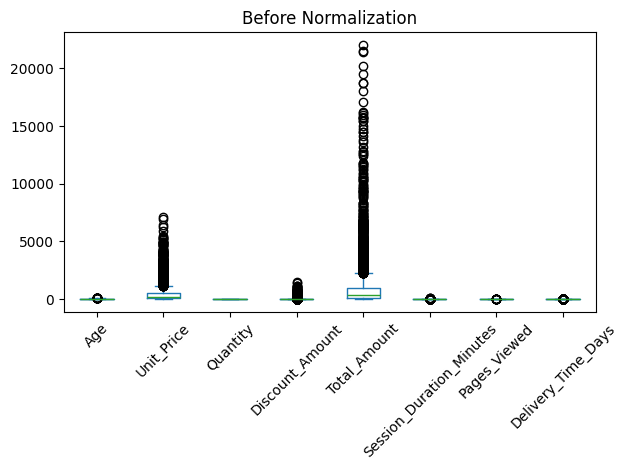

In [39]:
#Create boxplots for the original data:
plt.figure(figsize=(14, 6))

df[numeric_cols].plot(
    kind="box"
)

plt.title("Before Normalization")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

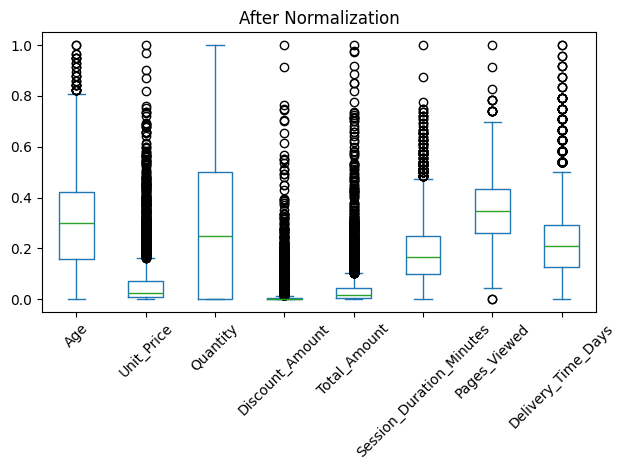

In [41]:
#Create boxplots for normalized data:
plt.figure(figsize=(14, 6))

df_normalized[numeric_cols].plot(
    kind="box"
)

plt.title("After Normalization")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

After normalization, all numerical attributes are placed on a common scale between 0 and 1. This makes attributes with large values and small values easier to compare. The original relationships between the values are same as before, but their numerical scale is changed.

# Task 15: Manual Normalization Experiment

Original value = 27

Minimum = 18

Maximum = 75

Manual normalized value = 0.1578947

Python normalized value = 0.157895

**There is no difference**

# Task 16: Mini Data-Mining Investigation

**Do returning customers have a higher average Total Amount than non-returning customers?**

Is_Returning_Customer
False    978.867527
True     985.960147
Name: Total_Amount, dtype: float64


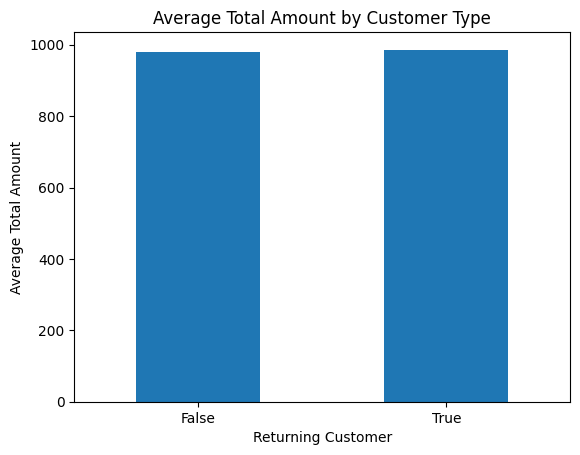

In [42]:
avg_amount = df.groupby("Is_Returning_Customer")["Total_Amount"].mean()

print(avg_amount)

avg_amount.plot(kind="bar")
plt.title("Average Total Amount by Customer Type")
plt.xlabel("Returning Customer")
plt.ylabel("Average Total Amount")
plt.xticks(rotation=0)
plt.show()

Returning customers spend slightly more per order on average than non-returning customers. However, the difference is small (about 7.09), so the two groups have very similar average spending in this dataset

**Does session duration differ between customers using different device types?**

Device_Type
Desktop    14.922852
Mobile     14.348837
Tablet     14.633603
Name: Session_Duration_Minutes, dtype: float64


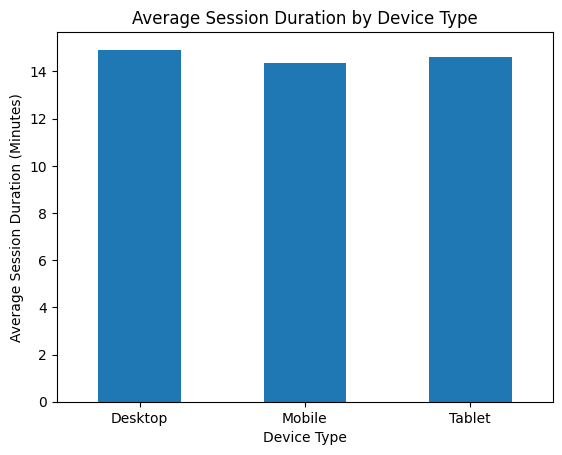

In [43]:
session_by_device = df.groupby("Device_Type")["Session_Duration_Minutes"].mean()

print(session_by_device)

session_by_device.plot(kind="bar")
plt.title("Average Session Duration by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Average Session Duration (Minutes)")
plt.xticks(rotation=0)
plt.show()

Session duration varies slightly across device types. Desktop users spend the most time on average, while mobile users spend the least. However, the differences are small, so device type does not appear to have a large effect on session duration in this dataset.

# Task 17: Data-Mining Detective Challenge

In [44]:


data = {
    "Attribute": [
        "Total_Amount",
        "Session_Duration_Minutes",
        "Product_Category",
        "Unit_Price",
        "Payment_Method",
        "Customer_ID"
    ],
    "Decision": [
        "Keep",
        "Keep",
        "Keep",
        "Transform",
        "Transform",
        "Remove"
    ],
    "Reason": [
        "Important numerical feature representing the total value of an order",
        "Useful behavioral feature showing how long a customer spends on the website",
        "Relevant categorical feature for comparing product groups",
        "Has a wide range, so normalization can be applied",
        "Categorical attribute should be converted into numerical representation",
        "Identifier only; not useful as an analytical feature"
    ]
}

table = pd.DataFrame(data)
table

,Attribute,Decision,Reason
0,Total_Amount,Keep,Important numerical feature representing the t...
1,Session_Duration_Minutes,Keep,Useful behavioral feature showing how long a c...
2,Product_Category,Keep,Relevant categorical feature for comparing pro...
3,Unit_Price,Transform,"Has a wide range, so normalization can be applied"
4,Payment_Method,Transform,Categorical attribute should be converted into...
5,Customer_ID,Remove,Identifier only; not useful as an analytical f...
